# Lecture 4: Becoming a Backprop Ninja — 初始化、BN 与训练诊断

跟随 Karpathy 的 [makemore](https://github.com/karpathy/makemore) 系列第 4 讲，深入探索**为什么初始化很重要**以及如何用 Batch Normalization 和训练诊断工具让深层网络稳定训练。

**学习路线：**
1. 浅层 MLP + 手动实现 Batch Normalization
2. 初始化诊断：Tanh 饱和、softmax 过度自信、loss 曲线
3. BN 的推理模式：EMA running statistics
4. Kaiming 初始化原理 & 用类封装的深层网络
5. 训练诊断四件套：激活分布、梯度分布、权重梯度、update/data 比率

## 0. 数据准备

复用第 3 讲的数据预处理流程：读取名字数据集 → 构建字符词表（27 个字符）→ 用滑动窗口生成 `(context → next_char)` 训练样本 → 按 80/10/10 划分训练/验证/测试集。

In [1]:
import torch
import torch.nn.functional as F          # 常用函数：cross_entropy, softmax 等
import matplotlib.pyplot as plt           # 绘图库，用于可视化 loss 曲线和直方图
%matplotlib inline

In [2]:
# ============================================================
# 读取数据集：每行一个英文名字
# ============================================================
# words = open('D:\\Vault-4\\Projects\\makemore\\names.txt', 'r').read().splitlines()
words = open("D:\\Obsidian Vaults\\Vault_4\\1 Project\\makemore\\names.txt", 'r').read().splitlines()
words[:8]                                # 预览前 8 个名字

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)                               # 数据集中名字的总数（约 32K）

32033

In [4]:
# ============================================================
# 构建字符词表 & 字符↔整数的映射表
# 26 个字母 + 1 个特殊符号 '.'（起始/终止标记）→ vocab_size = 27
# ============================================================
chars = sorted(list(set(''.join(words)))) # 取所有出现过的字符并排序
stoi = {s:i+1 for i,s in enumerate(chars)}# 字符→索引（a=1, b=2, ..., z=26）
stoi['.'] = 0                             # '.' 特殊标记 → 索引 0
itos = {i:s for s,i in stoi.items()}      # 索引→字符（反向映射）
vocab_size = len(itos)                    # 词表大小 = 27
vocab_size, itos

(27,
 {1: 'a',
  2: 'b',
  3: 'c',
  4: 'd',
  5: 'e',
  6: 'f',
  7: 'g',
  8: 'h',
  9: 'i',
  10: 'j',
  11: 'k',
  12: 'l',
  13: 'm',
  14: 'n',
  15: 'o',
  16: 'p',
  17: 'q',
  18: 'r',
  19: 's',
  20: 't',
  21: 'u',
  22: 'v',
  23: 'w',
  24: 'x',
  25: 'y',
  26: 'z',
  0: '.'})

In [5]:
# ============================================================
# 构建数据集：将名字转为 (context → next_char) 的训练样本
# block_size=3 表示用前 3 个字符预测下一个字符
# ============================================================
block_size = 3  # 上下文长度：用几个字符来预测下一个

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size       # 初始上下文全填 '.'（索引 0）
        for ch in w + '.':               # 遍历名字的每个字符 + 终止符
            ix = stoi[ch]                # 当前字符的索引
            X.append(context)            # 输入：当前上下文窗口
            Y.append(ix)                 # 标签：下一个字符的索引
            context = context[1:] + [ix] # 滑动窗口：去掉最早的，加入当前字符
    X = torch.tensor(X)                  # shape: (N, block_size)
    Y = torch.tensor(Y)                  # shape: (N,)
    print(X.shape, Y.shape)
    return X, Y


In [6]:

# ============================================================
# 按 80/10/10 比例划分训练集/验证集/测试集
# ============================================================
import random
random.seed(42)                          # 固定随机种子，确保每次运行结果相同
random.shuffle(words)                    # 打乱名字顺序
n1 = int(0.8*len(words))                 # 训练集截止位置
n2 = int(0.9*len(words))                 # 验证集截止位置
Xtr, Ytr = build_dataset(words[:n1])     # 训练集（80%）
Xdev, Ydev = build_dataset(words[n1:n2]) # 验证集（10%）
Xte, Yte = build_dataset(words[n2:])     # 测试集（10%）



torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 1. 浅层 MLP + 手动 Batch Normalization

**概念解释：** 这一部分在第 3 讲的 MLP 基础上，加入 Batch Normalization（BN）来稳定训练。上一讲我们发现两个问题：(1) Tanh 神经元在训练初期大量饱和，梯度消失；(2) 初始 loss 远大于理论值 3.296（softmax 过度自信）。BN 正是解决这些问题的关键技术。

**直觉理解：** BN 的核心思想非常简单——在每一层的线性变换之后、激活函数之前，把数据"拉回"到均值 0、标准差 1 的范围。为什么？因为 Tanh 的"甜区"（梯度较大的区域）恰好在 0 附近。如果输入值偏离太远（比如全是 5 或 -5），Tanh 输出就会卡在 ±1，梯度几乎为零，网络就"学不动"了。

### BN 公式

$$\hat{x}_{ij} = \gamma_j \cdot \frac{x_{ij} - \mu_j}{\sigma_j} + \beta_j$$

逐项解读：
- $\mu_j, \sigma_j$ = 当前 mini-batch 的均值和标准差（沿 batch 维度计算）
- 减均值、除标准差 → 标准化到 N(0,1)
- $\gamma_j$（`bngain`）和 $\beta_j$（`bnbias`）→ 可学习的缩放和偏移，让网络自己决定最终分布

**思路链**：原始数据 → 减均值（中心化）→ 除标准差（归一化）→ 此时是 N(0,1) → 乘 γ（调宽窄）→ 加 β（调位置）→ 最终分布由网络自己学出来

### 均值与标准差

`hpreact` 的形状是 $(B, n\_hidden) = (32, 200)$，其中 $B$ = `batch_size` = 32（mini-batch 中的样本数），**不是** `vocab_size`（27）。

```
hpreact 的形状 (32, 200)：

          神经元 0   神经元 1   ...   神经元 199
样本 0  [ 0.3,     -1.2,     ...,   0.7  ]
样本 1  [ 0.5,      0.8,     ...,  -0.3  ]
  ...
样本 31 [-0.1,      0.4,     ...,   1.1  ]
         ↑                          ↑
     dim=0 方向求均值/标准差（跨 32 个样本）
```

BN 是沿 **dim=0（batch 维度）** 计算的：对每个神经元，把它在 32 个样本上的值取均值和标准差。

对**第 $j$ 个神经元**：

$$\mu_j = \frac{1}{B}\sum_{i=1}^{B} x_{ij}, \quad \sigma_j = \sqrt{\frac{1}{B}\sum_{i=1}^{B}(x_{ij} - \mu_j)^2}$$

### 标准差的多角度理解

标准差 $\sigma$ 本质上度量的是数据的"散开程度"，可以从三个角度理解：

- **统计视角**：每个点到均值的**典型距离**（均方根距离）。$\sigma$ 小 → 点挤在一起；$\sigma$ 大 → 点分散开
- **几何视角**：把数据点想象成空间中的一团点云，$\sigma$ 就是这团云的**半径**
- **线性代数视角**：把去均值后的数据看作向量 $\vec{v} = (x_1 - \mu, ..., x_N - \mu)$，则 $\sigma = ||\vec{v}||_2 / \sqrt{N}$，即**向量长度除以 $\sqrt{N}$**

> 在本 notebook 中，激活值的 std 直接反映了神经元输出的"散开程度"：std ≈ 0 意味着所有输出几乎相同（没有区分度），std 接近 1 意味着值铺满了 tanh 的整个范围（可能饱和）。

### 高斯分布（正态分布）

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

标准化后 $\mu=0, \sigma=1$，简化为标准正态分布：

$$f(x) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{x^2}{2}\right)$$

**两个参数对曲线形状的控制：**

| 参数 | 控制曲线的 | 直觉 |
|------|-----------|------|
| $\mu$（均值） | **左右位置**（峰值中心在哪） | $\mu=0$ → 峰在原点；$\mu=3$ → 整条曲线右移 3 |
| $\sigma$（标准差） | **胖瘦**（数据的分散程度） | $\sigma$ 小 → 又高又窄（数据集中）；$\sigma$ 大 → 又矮又宽（数据分散） |

> 所以 BN 中 $\beta$（`bnbias`）对应 $\mu$，控制曲线左右移动；$\gamma$（`bngain`）对应 $\sigma$，控制曲线胖瘦。

### 为什么需要 `bngain`（γ）和 `bnbias`（β）？

标准化让数据回到 N(0,1) 是为了**安全起步**（防止 tanh 饱和）。但如果**强制**每层都是 N(0,1)，网络的表达能力就被限死了——也许某个神经元需要均值=0.5、标准差=1.3 才能最好地完成任务。

**一句话：先标准化保底，再用 γ/β 恢复自由度。**

- 初始状态：`bngain=1, bnbias=0` → 就是标准 N(0,1)，安全起步
- 训练后：网络可能把它调成 N(0.3, 0.8) 或任何它觉得最优的分布

| 参数 | 符号 | 调整的是 | 初始值 | 效果举例 |
|------|------|---------|--------|---------|
| `bnbias` | $\beta$ | **均值**（分布中心位置） | 0 | $\beta=0.5$ → 分布右移 0.5 |
| `bngain` | $\gamma$ | **标准差**（分布宽窄） | 1 | $\gamma=2$ → 分布变宽一倍 |

### `bngain` 和 `bnbias` 的形状

```python
bngain = torch.ones((1, n_hidden))    # shape: (1, 200)
bnbias = torch.zeros((1, n_hidden))   # shape: (1, 200)
```

- 第二维 = `n_hidden = 200`：**每个神经元各有一对 γ 和 β**，因为每个神经元的最优分布不同
- 第一维 = `1`：用于广播——一个 $\gamma_j$ 值对该神经元的**所有 batch 样本**都一样

**生活类比：** BN 就像老师在批改作文前先把所有学生的分数标准化——把平均分调到 60 分，标准差调到 10 分。这样不管是哪个班交上来的（不同 mini-batch），评判标准都是一致的。然后 $\gamma$ 和 $\beta$ 就像最终的"难度系数"和"起评分"，由系统自动学习调整。

In [ ]:
# ============================================================
# 定义浅层 MLP + 手动 Batch Normalization 参数
# 架构：Embedding(27→10) → Linear(30→200) → BN → Tanh → Linear(200→27)
# ============================================================
n_embd = 10                              # 字符嵌入维度
n_hidden = 200                           # 隐藏层神经元数量

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)  # 嵌入矩阵 (27, 10)

# W1 权重用 Kaiming 初始化：除以 sqrt(fan_in)，再乘 5/3 补偿 tanh 的方差压缩
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * (5/3) / ((block_size*n_embd)**0.5)
# b1 被移除了——因为 BN 会先减去均值，偏置项会被直接抵消，加了也白加
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01  # 输出层权重，初始化很小 → 初始 logits 接近 0 → 均匀分布
b2 = torch.randn(vocab_size, generator=g) * 0                 # 输出层偏置，初始化为 0

# BN 的可学习参数：缩放因子 γ 和偏移量 β
bngain = torch.ones((1, n_hidden))       # γ，初始 = 1（不缩放）
bnbias = torch.zeros((1, n_hidden))      # β，初始 = 0（不偏移）

# 指数移动平均（EMA）维护的全局统计量，供推理时替代 mini-batch 统计量
# 初始值：mean=0, std=1（标准正态假设）
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2]             # 注意：b1 已移除，bngain/bnbias 也在列表中
for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters), 'parameters')

### BN 的作用与代码实现

训练循环中这一行是手动实现的 BN（公式详见上方）：
```python
hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
```

**BN 解决了三个问题：**

1. **防止 tanh 饱和**：将 `hpreact` 拉回均值 0、标准差 1 的范围，让大部分值落在 tanh 的线性区（约 $[-1,1]$），避免梯度消失
2. **解耦层间依赖**：前面层参数变化不会让后面层输入分布漂移（Internal Covariate Shift）
3. **降低对初始化的敏感度**：即使初始化不佳，BN 也会自动把分布拉正

### Mini-batch 噪声 → 免费的正则化

因为 $\mu, \sigma$ 是在**随机抽取的 mini-batch**（这里 batch_size=32）上计算的，不是全局精确统计量，所以同一个样本在不同 batch 中会得到略不同的标准化结果。这种"抖动"等价于给网络注入了噪声，迫使网络学习对扰动鲁棒的特征，天然起到 **正则化** 效果（类似 Dropout）。batch 越小噪声越大。

> 推理时不能用 mini-batch 统计量（否则预测会抖动），需要用训练期间的全局 running mean/std。

In [ ]:
# ============================================================
# 训练循环：手动实现 Batch Normalization 的前向传播
# ============================================================
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # ---- 1. 构造 mini-batch ----
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]           # 随机抽取 batch_size 个样本

    # ---- 2. 前向传播 ----
    emb = C[Xb]                          # 字符嵌入查表 → (32, 3, 10)
    embcat = emb.view(emb.shape[0], -1)  # 拼接 3 个嵌入向量 → (32, 30)
    hpreact = embcat @ W1                # 线性变换 → (32, 200)，不加 b1（BN 会减均值）

    # ---- 3. 手动 Batch Normalization ----
    # 沿 batch 维度（dim=0）计算当前 mini-batch 的均值和标准差
    bnmeani = hpreact.mean(0, keepdim=True)   # shape: (1, 200)
    bnstdi = hpreact.std(0, keepdim=True)     # shape: (1, 200)
    # 标准化 + 可学习的缩放和偏移
    hpreact = bngain * (hpreact - bnmeani) / (bnstdi + 1e-5) + bnbias  # +1e-5 防止除零

    h = torch.tanh(hpreact)              # Tanh 激活 → (32, 200)
    logits = h @ W2 + b2                 # 输出层 → (32, 27)
    loss = F.cross_entropy(logits, Yb)   # 交叉熵损失

    # ---- 4. 用 EMA 在训练过程中维护全局 mean/std，供推理时使用 ----
    # momentum=0.001: running 值 ≈ 反映最近 ~1000 个 batch 的平均，非常平滑
    # 不参与梯度计算（torch.no_grad），这是簿记操作而非可学习参数
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # ---- 5. 反向传播 ----
    for p in parameters:
        p.grad = None                    # 清零梯度（比 zero_() 更高效）
    loss.backward()

    # ---- 6. 参数更新（SGD） ----
    lr = 0.1 if i < 100000 else 0.01     # 学习率衰减：前 100K 步用 0.1，之后用 0.01
    for p in parameters:
        p.data += -lr * p.grad           # 梯度下降：参数 -= lr × 梯度

    # ---- 7. 记录 & 打印 ----
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.item())

## 2. 初始化诊断：为什么初始 loss 很重要？

训练结束后我们会检查三件事来评估初始化质量：

1. **Tanh 饱和度**：有多少神经元的输出 |h| > 0.99？（越少越好）
2. **激活值分布**：h 和 hpreact 的直方图是否合理？
3. **初始 loss**：是否接近理论值 $-\log(1/27) \approx 3.296$？

如果初始 loss 远大于 3.296，说明模型在第一步就"自信地猜错了"——某些类别被赋予了极高概率，而正确答案的概率很低。这通常是因为 W2 的初始化值太大，导致 logits 的绝对值很大，softmax 输出变得极端。

**生活类比：** 一个刚入学的新生被问"你觉得期末考试会考什么？"。合理的回答是"不确定，每个话题都有可能"（均匀分布，loss ≈ 3.3）。不合理的是"我 100% 确定考微积分！"——如果考的不是微积分，这个自信的错误答案会受到很大惩罚（loss 爆炸）。

In [ ]:
# ============================================================
# 可视化 Tanh 饱和情况：白色像素 = |h| > 0.99（神经元"卡死"在 ±1）
# 行 = 样本，列 = 隐藏层神经元。理想情况下应该几乎全黑（很少饱和）
# ============================================================
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')

In [ ]:
# Tanh 输出 h 的分布直方图
#   理想：均匀分布在 (-1, 1) 之间；
# 不理想：两端 ±1 处出现尖峰（饱和）
plt.hist(h.view(-1).tolist(), 50);

In [ ]:
# BN 后、Tanh 前的 hpreact 分布直方图
# 经过 BN 后应该接近标准正态分布（均值≈0，标准差≈1）
plt.hist(hpreact.view(-1).tolist(), 50);

In [ ]:
# 验证 BN 效果：标准化后 hpreact 应接近 mean≈0, std≈1
hpreact.mean(), hpreact.std()

In [ ]:
# ============================================================
# 演示：Softmax "过度自信" 问题
# 当 logits 初始值过大时，softmax 会给某一个类极高的概率，
# 对应的 -log(p) 损失就会非常大 → 初始 loss 爆炸
# 解决方案：初始化 W2 时乘以很小的值（如 0.01），让初始 logits ≈ 0
# ============================================================
# logits = torch.randn(4) * 0.1            # 模拟 4 类的 logits（很小 → 接近均匀）
logits = torch.randn(4) * 10
probs = torch.softmax(logits, dim=0)     # 转为概率分布
loss = max(-probs.log())                 # 最坏情况下的 NLL
logits, probs, loss

In [ ]:
# 理论最优初始 loss：如果模型完全不确定（27 类均匀分布），loss = -log(1/27)≈ 3.296。
# 如果初始 loss 远大于此，说明初始化有问题（模型"过度自信"地猜错了）
-torch.tensor(1/27).log()

In [ ]:
# 绘制训练过程中的 loss 曲线（每一步记录一个点）
# 应该看到 loss 从 ~3.3 快速下降，最终趋于平稳
plt.plot(lossi)

## 3. BN 推理模式与模型评估

训练时 BN 用的是每个 mini-batch 的统计量（均值、标准差），但推理时我们需要**确定性**的结果——同一个输入每次都应该得到相同的输出。

**两种获取全局统计量的方法：**

1. **训练后校准**（已弃用）：训练结束后，把整个训练集跑一遍前向传播，精确计算全局 mean/std
2. **指数移动平均（EMA）**（推荐）：训练过程中每一步都用 `running = 0.999 × running + 0.001 × batch_stat` 平滑积累

**生活类比：** 这就像计算一个城市的"平均气温"。方法 1 是年底把 365 天的温度全部重新平均一遍——精确但费时。方法 2 是每天更新一次滑动平均——不需要存储历史数据，随时可用，而且在数据量够大时误差极小。PyTorch 的 `nn.BatchNorm1d` 默认使用方法 2。

> **💡 深入理解：** 为什么 momentum 设为 0.001 这么小？
>
> momentum 越小，running 统计量越"平滑"（反映更长时间段的平均），对单个 mini-batch 的波动越不敏感。0.001 意味着大约需要 ~1000 个 batch 才能让 running 值"追上"真实分布。这对于 200K 步的训练来说绰绰有余，但如果训练步数很少，就需要增大 momentum（如 PyTorch 默认的 0.1）。

In [ ]:
# ============================================================
# [已弃用] BN 校准的另一种方法：训练结束后，用整个训练集做一次前向传播
# 来精确计算全局 mean/std。现在改用 EMA（running mean/std）替代。
# 保留此代码供对比参考。
# ============================================================
# 训练结束后校准 BN：计算整个训练集的全局 mean/std
# 训练时用的是 mini-batch 的统计量（有噪声），推理时需要稳定的全局统计量
with torch.no_grad():
    # 对整个训练集做一次前向传播（不需要梯度）
    emb=C[Xtr] 
    embcat=emb.view(emb.shape[0],-1) 
    hpreact=embcat @ W1 # + b1 
    # 在全部训练样本上计算每个神经元的均值和标准差 → 形状 (1, n_hidden)
    bnmean=hpreact.mean(0,keepdim=True) 
    bnstd=hpreact.std(0,keepdim=True)
# 现在用 bnmean_running 和 bnstd_running 就可以在推理时使用——
# 不需要单独跑校准步骤，训练过程中 EMA 已经自动维护了全局统计量

In [ ]:
# 对比 mini-batch 统计量 vs EMA 全局统计量
# bnmean: 最后一个 mini-batch 的局部均值（每个 batch 都不同，有噪声）
# bnmean_running: EMA 维护的全局均值（训练过程中平滑积累，适合推理）
bnmean, bnmean_running

In [ ]:
# ============================================================
# 评估函数：在训练集/验证集/测试集上计算 loss
# 推理时使用全局 bnmean/bnstd 而非 mini-batch 统计量
# ============================================================
@torch.no_grad()                         # 禁用梯度追踪，节省显存和计算
def spilt_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]                           # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # (N, block_size*n_embd)
    hpreact = embcat @ W1                # (N, n_hidden)，不加 b1

    # 关键：推理时用全局 bnmean/bnstd 而不是当前 batch 的统计量
    # 这保证了同一个输入每次预测结果都一样（确定性推理）
    hpreact = bngain * (hpreact - bnmean) / (bnstd + 1e-5) + bnbias
    h = torch.tanh(hpreact)              # (N, n_hidden)
    logits = h @ W2 + b2                 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

spilt_loss('train')
spilt_loss('dev')

In [ ]:
# 检查中间张量的形状，帮助调试维度问题
# embcat: (N, 30), W1: (30, 200), hpreact: (N, 200)
embcat.shape, W1.shape, hpreact.shape

In [ ]:
# ============================================================
# 从训练好的模型中采样生成新名字
# 流程：初始上下文 [...] → 逐字符预测 → 直到生成终止符 '.'
# ============================================================
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):                      # 生成 20 个名字
    out = []
    context = [0] * block_size           # 初始上下文全是 '.'
    while True:
        # 前向传播当前上下文
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        # h = torch.tanh(emb.view(1, -1) @ W1 + b1)  # (1, n_hidden)
        h = torch.tanh(emb.view(1, -1) @ W1 )  # (1, n_hidden)
        logits = h @ W2 + b2            # (1, vocab_size)
        probs = F.softmax(logits, dim=1) # 转为概率分布

        # 按概率分布随机采样下一个字符
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # 滑动上下文窗口 & 记录生成的字符
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:                      # 生成了终止符 '.' → 一个名字生成完毕
            break

    print(''.join(itos[i] for i in out)) # 将索引序列解码为字符串并打印

In [ ]:
# ============================================================
# Loss 变化记录：每次改进后的 train/val loss 对比
# 可以清楚看到每个优化技巧的贡献
# ============================================================
# original（未优化基线）:
#   train 2.1245  val 2.1682
#
# + fix softmax（W2 *= 0.01，避免初始 loss 爆炸）:
#   train 2.07    val 2.13
#
# + Kaiming init（W1 除以 sqrt(fan_in)）:
#   train 2.0356  val 2.1027
#
# + BatchNorm（加入 BN 层）:
#   train 2.0786  dev 2.1128
#
# + 去掉 b1 + momentum=0.001:
#   train 2.4232  dev 2.4459

## 4. 从浅到深：Kaiming 初始化与模块化网络

前面用一个隐藏层 + 手写 BN 实验了初始化的重要性。现在要进入"正式"模式：

1. **Kaiming 初始化演示**：为什么权重要除以 $\sqrt{fan\_in}$？
2. **用类封装层**：Linear、BatchNorm1d、Tanh —— 和 PyTorch 官方接口一模一样
3. **搭建 5 层深网络**：观察深度带来的新挑战

**直觉理解：** 想象一排人在传话——如果每个人说话的音量都比上一个人大一点，到最后一个人就变成了尖叫（梯度爆炸）；如果每个人的音量都缩小一点，到最后就听不见了（梯度消失）。Kaiming 初始化的目标就是让每个人说话的音量保持一致。

**类比：** Kaiming 初始化就像调音台上的"音量标准化"——不管输入通道有多少条，混音后的总音量始终保持一致。输入通道越多（fan_in 越大），每条通道的音量就要调得越小。

### 为什么需要 Kaiming 初始化？——数学推导

```python
W1 = torch.randn((30, 200)) * (5/3) / (30**0.5)
#    ├─ 标准正态随机数 ────┘     │       │
#    ├─ × (5/3) ── 补偿 tanh 方差压缩。  │
#    └─ ÷ √fan_in ── Kaiming 核心  ─────┘
```

---

#### 1. 为什么矩阵乘法会放大标准差？

`embcat @ W1` 的本质：对输出的**每一个神经元**，都是把输入的 `fan_in` 个值与 W1 对应**一列**的权重逐一相乘再求和：

```
embcat (1, 30)          W1 (30, 200)
                        列 j
[x₁, x₂, ..., x₃₀] @ [w₁ⱼ]     → yⱼ = x₁w₁ⱼ + x₂w₂ⱼ + ... + x₃₀w₃₀ⱼ
                     [w₂ⱼ]          = Σ xₖwₖⱼ  ← 30 个随机数相加！
                     [ ⋮ ]
                     [w₃₀ⱼ]
```

用 fan_in=3 的简化例子推导方差变化：

$$y = x_1 w_1 + x_2 w_2 + x_3 w_3$$

如果 $x_k \sim N(0,1)$，$w_k \sim N(0,1)$，互相独立：

> **为什么均值是 0？** 因为 `torch.randn` 就是从标准正态分布 $N(0,1)$ 中采样——均值=0，标准差=1。代码中 `C = torch.randn(...)` 和 `W1 = torch.randn(...)` 都是这样初始化的，所以 `embcat`（从 `C` 查表得到）和 `W1` 的值在初始化时都近似零均值。

**第一步——单个乘积 $x_k w_k$ 的方差：**

$\text{Var}(x_k w_k)$ 是"一个输入值 × 一个权重值"这个乘积的离散程度。用方差公式 $\text{Var}(Z) = E[Z^2] - (E[Z])^2$ 展开：

$$\text{Var}(x_k w_k) = E[(x_k w_k)^2] - (E[x_k w_k])^2$$

因为 $x_k$ 和 $w_k$ **独立**，乘积的期望 = 各自期望的乘积：

$$E[x_k w_k] = E[x_k] \cdot E[w_k] = 0 \times 0 = 0$$

$$E[(x_k w_k)^2] = E[x_k^2 \cdot w_k^2] = E[x_k^2] \cdot E[w_k^2]$$

代入方差公式：

$$\text{Var}(x_k w_k) = E[x_k^2] \cdot E[w_k^2] - 0^2 = E[x_k^2] \cdot E[w_k^2]$$

又因为 $E[x_k]=0$，所以 $E[x_k^2] = \text{Var}(x_k) + (E[x_k])^2 = \text{Var}(x_k)$，同理 $E[w_k^2] = \text{Var}(w_k)$：

$$\text{Var}(x_k w_k) = \text{Var}(x_k) \cdot \text{Var}(w_k) = 1 \times 1 = 1$$

> 关键前提：**独立** + **零均值**。如果均值不为零，公式会更复杂。

  > **方差公式的推导：**
  >
  > $$\begin{aligned}
  > \text{Var}(X) &= E[(X - E[X])^2] \\
  > &= E[X^2 - 2X\,E[X] + E[X]^2] \\
  > &= E[X^2] - 2\,E[X]\,E[X] + E[X]^2 \\
  > &= E[X^2] - E[X]^2
  > \end{aligned}$$

**第二步——求和后的方差**（独立随机变量的方差可加）：

$$\text{Var}(y) = \text{Var}(x_1 w_1) + \text{Var}(x_2 w_2) + \text{Var}(x_3 w_3) = 1+1+1 = 3$$

$$\text{Std}(y) = \sqrt{3} \approx 1.73$$

**推广到 fan_in=30：** $\text{Var}(y) = 30$，$\text{Std}(y) = \sqrt{30} \approx 5.48$

输入 std=1，经过一层线性变换后 std 变成了 5.48！再过下一层又放大 $\sqrt{fan\_in}$ 倍 → 逐层指数增长 → **梯度爆炸**。

**Kaiming 的修复：** 让 $w_k \sim N(0, \frac{1}{fan\_in})$，即除以 $\sqrt{fan\_in}$：

$$\text{Var}(y) = \sum_{k=1}^{n} \text{Var}(x_k) \cdot \text{Var}(w_k) = n \cdot 1 \cdot \frac{1}{n} = 1 \quad \checkmark$$

---

#### 2. tanh 是怎么把方差压缩到约 3/5 的？

tanh 的形状决定了它会"吃掉"一部分方差：

| 输入范围 | tanh 行为 | 对方差的影响 |
|---------|----------|------------|
| $\|x\| < 1$（约 68% 的样本） | $\tanh(x) \approx x$，斜率 $\approx 1$ | 几乎不压缩 |
| $\|x\| > 1$（约 32% 的样本） | $\tanh(x) \to \pm 1$，曲线变平 | 大幅压缩 |

直觉：tanh 保留了中间的值，但把尾部的"大值"全压成了 $\pm 1$ → 分布变窄 → 方差缩小。

**Taylor 展开近似推导：**

$\tanh(x)$ 在 $x=0$ 处展开：

$$\tanh(x) = x - \frac{x^3}{3} + \frac{2x^5}{15} - \cdots \approx x - \frac{x^3}{3}$$

对 $x \sim N(0,1)$ 取方差（利用 $E[\tanh(x)]=0$，因为 tanh 是奇函数）：

$$\text{Var}(\tanh(x)) = E[\tanh^2(x)] \approx E\!\left[\left(x - \frac{x^3}{3}\right)^2\right] = E\!\left[x^2 - \frac{2x^4}{3} + \frac{x^6}{9}\right]$$

代入标准正态的各阶矩 $E[x^2]=1,\ E[x^4]=3,\ E[x^6]=15$：

$$\text{Var}(\tanh(x)) \approx 1 - \frac{2 \times 3}{3} + \frac{15}{9} = 1 - 2 + \frac{5}{3} \approx 0.67$$

> Taylor 展开是近似，实际数值积分结果约为 **0.58–0.6**，取整约为 $\frac{3}{5}$。

---

#### 补充 A：为什么 Taylor 展开在 x=0，却能估算 |x|>1 处的压缩？

Taylor 展开 $\tanh(x) \approx x - x^3/3$ 在单点 |x|>1 处确实不准（如 x=2 时，$\tanh(2)=0.96$，但 $2 - 8/3 = -0.67$）。但我们算的不是单点，而是**所有 x 的加权平均**（期望）：

$$E[\tanh^2(x)] = \int_{-\infty}^{\infty} \tanh^2(x) \cdot \underbrace{\frac{1}{\sqrt{2\pi}} e^{-x^2/2}}_{\text{正态分布的权重}} dx$$

正态分布的权重在 |x|>2 处已经非常小（只有约 5% 的概率），所以尾部 Taylor 不准的区域被小权重压了下去：

```
正态分布的权重：
        ▄▄▄█████▄▄▄
     ▄██████████████▄
   ▄████████████████████▄
──────┼────┼────┼────┼──────
    -2    -1    0    1    2

|x|<1: 68% 的概率质量，Taylor 很准
|x|>1: 32% 的概率质量，Taylor 不准，但权重小
|x|>2: 只有 5%，几乎可以忽略
```

而高阶矩 $E[x^4]=3$、$E[x^6]=15$ 之所以很大，正是因为它们把尾部的值取了 4/6 次方放大了——这间接捕捉了 |x|>1 区域的贡献。

所以最终 Taylor 近似 ≈ 0.67，精确数值积分 ≈ 0.58–0.6，量级是对的但有约 15% 误差。**Taylor 展开这里是帮助理解的近似手段，不是精确证明。**

---

#### 补充 B：标准正态的各阶矩怎么算的？

"矩"就是 $E[x^n]$，即 $x^n$ 的期望（平均值）。对 $x \sim N(0,1)$：

- **奇数阶矩全为 0**（正态分布对称，正负抵消）
- **偶数阶矩有递推公式：** $E[x^{2k}] = (2k-1) \cdot E[x^{2(k-1)}]$

| 阶矩 | 递推 | 结果 |
|------|------|------|
| $E[x^2]$ | $= \text{Var}(x) = 1$ | **1** |
| $E[x^4]$ | $= 3 \times E[x^2] = 3 \times 1$ | **3** |
| $E[x^6]$ | $= 5 \times E[x^4] = 5 \times 3$ | **15** |

**递推公式的来源——分部积分：** 以 $E[x^4]$ 为例：

$$E[x^4] = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty} x^4 \cdot e^{-x^2/2}\, dx$$

令 $u = x^3$，$dv = x \cdot e^{-x^2/2}\,dx$，则 $du = 3x^2\,dx$，$v = -e^{-x^2/2}$：

$$E[x^4] = \frac{1}{\sqrt{2\pi}} \underbrace{\left[x^3 \cdot (-e^{-x^2/2})\right]_{-\infty}^{\infty}}_{=\,0\text{（指数衰减比多项式快）}} + \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} 3x^2 \cdot e^{-x^2/2}\,dx = 3 \cdot E[x^2] = 3$$

同理 $E[x^6]$：令 $u=x^5$，分部积分后 $= 5 \cdot E[x^4] = 15$。

**规律：每次分部积分"降两阶"，并乘出系数 $(2k-1)$。**

---

**补偿：** 乘以增益 $\frac{5}{3}$ 使线性变换输出的方差略大于 1，刚好抵消 tanh 的压缩，让每层激活值方差保持稳定。这个值就是 `torch.nn.init.calculate_gain('tanh')` 的返回值。

> 📄 原始论文：He et al., [*Delving Deep into Rectifiers*](https://arxiv.org/abs/1502.01852), 2015。论文针对 ReLU 推导，tanh 的增益系数是同一框架下的推广。

tensor(0.0094) tensor(1.0073)
tensor(0.0024) tensor(0.9931)


(array([2.08615073e-05, 0.00000000e+00, 0.00000000e+00, 6.25845218e-05,
        1.25169044e-04, 1.46030551e-04, 2.29476580e-04, 4.17230145e-04,
        7.92737276e-04, 1.62719757e-03, 2.00270470e-03, 3.46301020e-03,
        5.82036053e-03, 1.01386925e-02, 1.66474828e-02, 2.83090654e-02,
        4.43515644e-02, 6.71531919e-02, 1.01825017e-01, 1.50015099e-01,
        2.07446828e-01, 2.67402800e-01, 3.38728293e-01, 3.93781811e-01,
        4.20463679e-01, 4.28829143e-01, 3.95033501e-01, 3.45216222e-01,
        2.76414971e-01, 2.10263132e-01, 1.53832755e-01, 1.06581441e-01,
        7.23059842e-02, 4.65002997e-02, 3.01031550e-02, 1.81077883e-02,
        1.08062608e-02, 6.92602041e-03, 4.36005502e-03, 2.73285745e-03,
        1.46030551e-03, 7.09291247e-04, 4.79814667e-04, 2.71199594e-04,
        1.87753565e-04, 1.04307536e-04, 6.25845218e-05, 0.00000000e+00,
        2.08615073e-05, 2.08615073e-05]),
 array([-6.00405741, -5.76438153, -5.52470566, -5.28502978, -5.04535391,
        -4.80567803, 

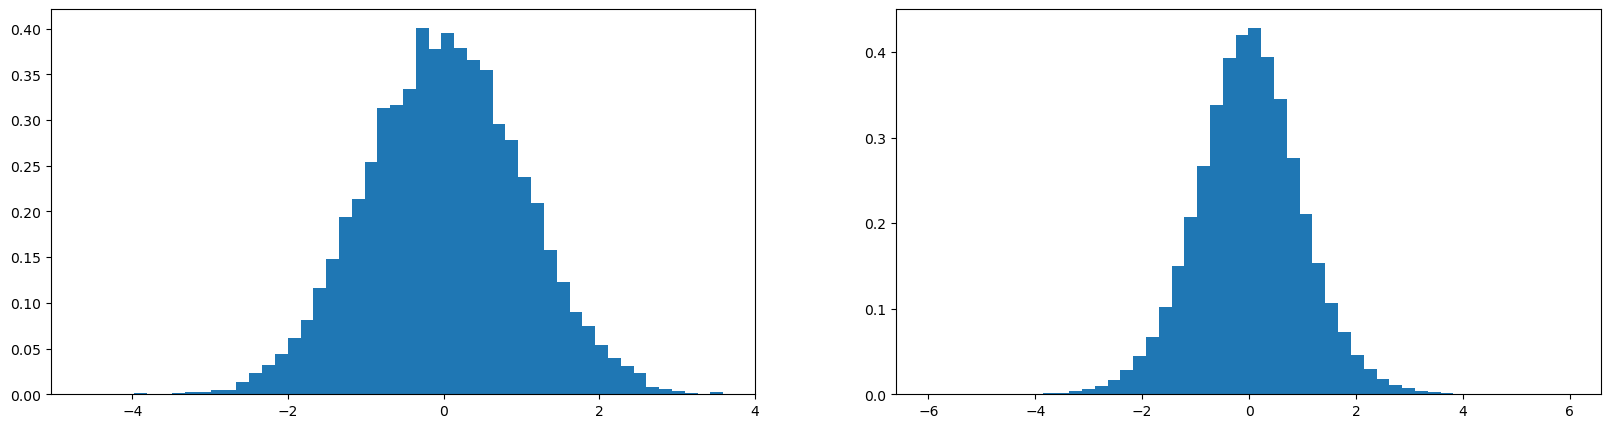

In [7]:
# ============================================================
# 演示 Kaiming 初始化的原理：为什么要除以 sqrt(fan_in)？
# 如果输入 x ~ N(0,1)，权重 w ~ N(0,1)，那么 y = x @ w 的标准差 = sqrt(fan_in)
# 除以 sqrt(fan_in) 后，输出 y 的标准差重新回到 ≈ 1
# ============================================================
x = torch.randn(1000, 10)               # 1000 个样本，10 维输入（fan_in=10）
w = torch.randn(10, 200) / 10**0.5      # 权重除以 sqrt(10) → Kaiming 初始化
y = x @ w                               # 矩阵乘法 → (1000, 200)
print(x.mean(), x.std())                # 输入：mean≈0, std≈1
print(y.mean(), y.std())                # 输出：mean≈0, std≈1（被 Kaiming 保持住了！）

plt.figure(figsize=(20,5))
plt.subplot(121)                         # 左图：输入 x 的分布
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)                         # 右图：输出 y 的分布（应该也是标准正态）
plt.hist(y.view(-1).tolist(), 50, density=True)

In [40]:
# ============================================================
# 用类封装的深层网络：5 层隐藏层 + BatchNorm1d
# 架构：Embedding → [Linear → BN → Tanh] × 5 → Linear → Softmax
# 这是"正式"写法，替代前面手写的单层 BN
# ============================================================

class Linear:
    """线性层：y = x @ W + b"""
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / (fan_in**0.5)  # Kaiming 初始化, 这本来是可以保持。但是后面用了tanh，所以乘以 5/3 补偿
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight       # 矩阵乘法
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:
    """批归一化层：训练时用 mini-batch 统计量，推理时用 running 统计量"""
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps                   # 防止除零的小常数
        self.momentum = momentum         # EMA 动量（0.1 → 近 ~10 个 batch 的平均）
        self.training = True             # 训练/推理模式开关
        # 不存 self.dim：dim 只用于下面创建张量的形状，
        # 之后维度信息已编码在张量 shape 中，__call__ 靠广播自动匹配，无需再引用

        # 可学习参数（通过反向传播更新）
        self.gamma = torch.ones((1, dim))   # 缩放因子 γ，初始 = 1
        self.beta = torch.zeros((1, dim))   # 偏移量 β，初始 = 0

        # 缓冲区（通过 EMA 更新，不参与梯度计算）
        self.running_mean = torch.zeros((1, dim))
        self.running_var = torch.ones((1, dim))

    def __call__(self, x):
        # ---- 1. 根据模式选择统计量来源 ----
        if self.training:
            # 训练：用当前 mini-batch 实时计算（有噪声，但噪声起正则化作用）
            xmean = x.mean(0, keepdim=True)                    # batch 均值 (1, dim)
            xvar = x.var(0, keepdim=True, unbiased=False)       # batch 方差，用 1/N 非 1/(N-1)，与 PyTorch 官方 BN 一致
        else:
            # 推理：用 EMA 积累的全局统计量，保证同一输入每次输出一致
            xmean = self.running_mean
            xvar = self.running_var

        # ---- 2. BN 公式：标准化 → 缩放偏移 ----
        # xhat = (x - μ) / √(σ² + ε)  → N(0,1)
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)       # +eps 防止方差为 0 时除零
        # out = γ * xhat + β  → N(β, γ²)，让网络自己学最优分布
        self.out = self.gamma * xhat + self.beta

        # ---- 3. 训练时用 EMA 更新 running 统计量（簿记，不参与梯度） ----
        # 每步以 momentum 权重混入当前 batch 统计量，训练越久越接近全局真实分布
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        # 只有 γ 和 β 是可学习参数；running_mean/var 是 EMA 缓冲区，不参与梯度更新
        return [self.gamma, self.beta]
    

class Tanh:
    """Tanh 激活函数层"""
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [98]:

# ============================================================
# 组装 5 层深层网络
# ============================================================    
n_embd = 10                              # 嵌入维度
n_hidden = 100                           # 每层隐藏神经元数
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)  # 嵌入矩阵 (27, 10)

# layers = [                                         # 没有BatchNorm层，没有有Tanh层
#     Linear(block_size*n_embd, n_hidden),           # 第 1 层：30 → 100
#     Linear(         n_hidden, n_hidden),           # 第 2 层：100 → 100
#     Linear(         n_hidden, n_hidden),           # 第 3 层：100 → 100
#     Linear(         n_hidden, n_hidden),           # 第 4 层：100 → 100
#     Linear(         n_hidden, n_hidden),           # 第 5 层：100 → 100
#     Linear(         n_hidden, vocab_size),         # 输出层：100 → 27（无激活）
# ]

# layers = [                                                 # 没有BatchNorm层，有Tanh层
#     Linear(block_size*n_embd, n_hidden), Tanh(),           # 第 1 层：30 → 100
#     Linear(         n_hidden, n_hidden), Tanh(),           # 第 2 层：100 → 100
#     Linear(         n_hidden, n_hidden), Tanh(),           # 第 3 层：100 → 100
#     Linear(         n_hidden, n_hidden), Tanh(),           # 第 4 层：100 → 100
#     Linear(         n_hidden, n_hidden), Tanh(),           # 第 5 层：100 → 100
#     Linear(         n_hidden, vocab_size),                 # 输出层：100 → 27（无激活）
# ]

layers = [                                                                           # 有BatchNorm层，有Tanh层
    Linear(block_size*n_embd, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  # 第 1 层：30 → 100
    Linear(n_hidden, n_hidden, bias=False),          BatchNorm1d(n_hidden), Tanh(),  # 第 2 层：100 → 100
    Linear(n_hidden, n_hidden, bias=False),          BatchNorm1d(n_hidden), Tanh(),  # 第 3 层：100 → 100
    Linear(n_hidden, n_hidden, bias=False),          BatchNorm1d(n_hidden), Tanh(),  # 第 4 层：100 → 100
    Linear(n_hidden, n_hidden, bias=False),          BatchNorm1d(n_hidden), Tanh(),  # 第 5 层：100 → 100
    Linear(n_hidden, vocab_size),                    BatchNorm1d(vocab_size)         # 输出层：100 → 27（无激活）
]

with torch.no_grad():
    # 输出层权重 × 0.1 → 初始 logits 接近 0 → 均匀分布 → 避免初始 loss 爆炸
    # layers[-1].weight *= 0.1
    layers[-1].gamma *= 0.1 # 使用 BatchNorm 后，输出层的缩放因子 gamma 也需要乘以 0.1 来降低初始 logits 的尺度
    # 其他 Linear 层权重 × 5/3 → 补偿 Tanh 的方差压缩
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            gain = 5/3              # 刚好抵消 tanh 的压缩
            # gain = 1                # tanh的压缩会导致激活收缩集中到0附近，NN变得不再活跃
            # gain = 2 # 会导致过补偿
            layer.weight *= gain          

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters), 'parameters')
for p in parameters:
    p.requires_grad = True

47051 parameters


### 为什么需要非线性激活（Tanh）？——纯线性堆叠的致命缺陷

上面代码中有三种网络配置：纯线性（无 Tanh）、有 Tanh、有 BN + Tanh。为什么不能只用线性层堆叠？

#### 1. 数学证明：多层线性 = 一层线性

```
层1: h₁ = W₁·x + b₁
层2: h₂ = W₂·h₁ + b₂
        = W₂·(W₁·x + b₁) + b₂
        = (W₂·W₁)·x + (W₂·b₁ + b₂)
        = W'·x + b'        ← 等价于单层线性变换！
```

无论堆 5 层还是 100 层，结果都坍缩为一次矩阵乘法 `y = W'x + b'`。网络的深度完全白费——**只能表达线性关系**。

Tanh 打破了这个限制：`h₂ = tanh(W₂ · tanh(W₁·x + b₁) + b₂)`，由于 tanh 的非线性"折弯"，`h₂` **不能**被简化成 `x` 的线性函数。每多一层，模型就能多学一层"折弯"，表达能力逐层增强。

| 方案 | 类比 | 能力 |
|------|------|------|
| 纯线性堆叠 | 拿一把直尺画图 | 只能画直线 |
| 线性 + Tanh | 拿一根可弯曲的铁丝 | 能弯成任意曲线 |

#### 2. 吴恩达的教学澄清

吴恩达说的是 **反过来** 的：

- **Hidden layer**：**必须**用非线性激活（ReLU、Tanh 等）—— 否则多层坍缩为一层
- **Output layer**：**可以**用线性激活 —— 取决于任务类型

| 任务 | Output layer 激活 | 原因 |
|------|-------------------|------|
| 回归（如预测房价） | 线性（不加激活） | 输出需要任意实数 |
| 二分类 | Sigmoid | 输出需要 0~1 概率 |
| 多分类（如本项目） | Softmax | 输出需要概率分布 |

所以 softmax 只解决最后一步（分数→概率），不能替代中间层的非线性。

#### 3. 诊断对比：纯线性下 `weight × 0.5` vs `weight × 2`

在纯线性网络中，每层的"乘数" k 就是权重本身，指数效应暴露无遗：

**weight × 0.5（每层缩小）：**

| 层 | 诊断 1（激活 std） | 诊断 2（梯度 std） |
|----|-------------------|-------------------|
| 层 1 | 0.5 | 相对大 |
| 层 2 | 0.25 (0.5²) | ↓ |
| 层 3 | 0.125 (0.5³) | ↓ |
| 层 5 | 0.03 (0.5⁵) | 几乎为 0 |

→ 激活坍缩到 0，梯度消失，前面的层学不动

**weight × 2（每层放大）：**

| 层 | 诊断 1（激活 std） | 诊断 2（梯度 std） |
|----|-------------------|-------------------|
| 层 1 | 2 | 巨大 |
| 层 2 | 4 (2²) | ↑ |
| 层 3 | 8 (2³) | ↑ |
| 层 5 | 32 (2⁵) | 爆炸 → inf/nan |

→ 激活爆炸，梯度爆炸，训练完全不稳定

#### 4. Tanh 提供了"可调旋钮"

| | 纯线性 | 有 Tanh |
|---|---|---|
| 每层的乘数 k | = weight 本身 | = weight × tanh'(x) |
| 控制手段 | 无法调节，k 就是 W | 可以通过初始化让 k ≈ 1 |
| W=0.5 | k=0.5 → 必然坍缩 | Kaiming + gain 5/3 补偿 → k ≈ 1 |
| W=2 | k=2 → 必然爆炸 | tanh 饱和区压制 → k 不会太大 |

**一句话总结：** Tanh 不只增加表达能力，还让梯度流动变得**可控**——它提供了额外的"旋钮"（tanh 的导数），让我们通过 Kaiming 初始化把每层的有效乘数 k 调到 ≈ 1。

### 为什么增益设为 `5/3`？—— Tanh 的方差压缩效应

`layer.weight *= 0.5` 或 `layer.weight *= 5/3` 这行代码的目的是控制每层激活值的方差。

**Tanh 会"压缩"方差：** tanh 的输出总是比输入小一点——靠近 0 的值几乎不变（斜率 ≈ 1），但离 0 越远的值被压得越多（曲线变平）。当输入服从标准正态分布时，经过 tanh 后方差大约降到原来的 **3/5**（≈ 0.6）。

**逐层累积效应：** 如果不补偿这个压缩，每过一层方差都乘以 0.6，5 层之后方差只剩 0.6⁵ ≈ 0.08，激活值全部坍缩到 0 附近。如果增益设得太小（如 0.5），情况更严重——方差每层乘以 0.25，5 层后几乎归零。

**5/3 是 3/5 的倒数**，刚好补偿 tanh 的压缩，让每层输出方差保持稳定：

| 增益值 | 每层方差变化 | 5层后效果 |
|--------|------------|----------|
| 0.5 | ×0.25 | 激活坍缩到 0 |
| 1.0 | ×0.6 | 缓慢衰减 |
| **5/3** | **≈×1.0** | **保持稳定 ✓** |
| 2.0 | ×2.4 | 激活饱和到 ±1 |

> 这个值也是 PyTorch 官方推荐的：`torch.nn.init.calculate_gain('tanh')` 返回的就是 `5/3`。

### 为什么 BatchNorm 让 `√fan_in` 和 `gain` 都不再必要？

前面花了大量篇幅讨论 Kaiming 初始化（`÷√fan_in`）和 tanh 增益补偿（`×5/3`），但一旦加了 BN，这些精心设计**全部变得不那么重要**了。原因如下：

#### 没有 BN：误差逐层指数累积

```
[Linear] → 方差 ×fan_in（爆炸！）→ [Tanh] → 方差 ×3/5（压缩！）→ [Linear] → ...
     ↑ 需要 ÷√fan_in 修复                ↑ 需要 ×5/3 补偿
```

每一层的输出分布**完全取决于**前面所有层的累积效果。一层差一点，5 层后就差几十倍。

#### 有 BN：每层独立重置

```
[Linear] → 方差随便多大 → [BN → N(0,1)] → [Tanh] → 方差被压缩 → [Linear] → 方差随便多大 → [BN → N(0,1)] → ...
                ↑ 不管了，BN 会修                                                  ↑ 不管了，BN 会修
```

BN **强制**把每层的输入拉回 N(0,1)，所以：

| 初始化问题 | 没有 BN | 有 BN |
|-----------|---------|-------|
| W 太大，方差爆炸 | 需要 `÷√fan_in` 压回来 | BN 直接除以 std，自动归一化 |
| tanh 压缩方差 | 需要 `×5/3` 补偿 | 下一层的 BN 会重新拉回 N(0,1) |
| 误差累积方式 | 逐层**指数**放大 | 每层独立重置，**无法累积** |
| 激活值分布 | 严重依赖初始化 | 始终在 tanh 甜区 |
| 梯度流动 | 初始化差 → 消失/爆炸 | 激活在甜区 → tanh'≈1 → 梯度稳定 |

#### 类比

- **没有 BN**：一排人传话，每个人的音量必须精确校准（Kaiming + gain），一个人声音大了后面全变成尖叫
- **有 BN**：每两个人之间放了一个**音量标准化器**，不管前面多大声，传到下一个人时自动调回正常音量

**一句话：`÷√fan_in` 和 `×5/3` 是在手动做 BN 自动做的事。有了 BN，初始化只要"不太离谱"就行。**

> 这也解释了为什么代码中第三种配置（BN + Tanh）即使把 `gain` 改成 1 或 2，诊断图仍然看起来健康——BN 在每层"兜底"。

In [99]:
# ============================================================
# 训练深层网络（5 层 MLP，无 BN）
# 注意：这里没有使用 BatchNorm1d，是为了对比观察初始化的效果
# ============================================================
max_steps = 200000
batch_size = 32
lossi = []
ud = []                                  # 记录 update-to-data 比率（诊断用）

for i in range(max_steps):
    # ---- 构造 mini-batch ----
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # ---- 前向传播：逐层传递 ----
    emb = C[Xb]                          # (32, 3, 10)
    x = emb.view(emb.shape[0], -1)      # (32, 30)
    for layer in layers:
        x = layer(x)                     # 依次通过每一层
    loss = F.cross_entropy(x, Yb)        # x 此时是 logits (32, 27)

    # ---- 反向传播 ----
    for layer in layers:
        layer.out.retain_grad()          # 保留中间激活的梯度，用于后续可视化
    # 💡 深入理解：`retain_grad()` 的作用
    # PyTorch 默认只保留叶子节点（`requires_grad=True` 的参数）的梯度，中间计算结果的梯度会被丢弃以节省显存。
    # 调用 `layer.out.retain_grad()` 告诉 PyTorch 保留这些中间激活的梯度，这样我们才能可视化每一层的梯度流动情况。生
    # 产代码中不需要这样做——这纯粹是诊断工具。

    for p in parameters:
        p.grad = None # 清零梯度（比 zero_() 更高效）
    loss.backward()

    # ---- SGD 更新 ----
    lr = 0.1 if i < 100000 else 0.01
    # lr = 0.001 # 学习率过小会导致 update/data 比率过小，模型几乎不学习
    # lr = 1.0   # 学习率过大导致 update/data 比率过大，训练震荡，loss 不下降
    for p in parameters:
        p.data += -lr * p.grad

    # ---- 记录统计量 ----
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())  # 记录 log10(loss) 以便可视化

    # ---- 记录 update/data 比率（诊断 4 的数据来源） ----
    # 问题：每步训练改变了参数的多大比例？
    # with torch.no_grad() → 纯记录诊断数据，不参与训练，关掉梯度追踪节省计算
    with torch.no_grad():
        # 列表推导式：对每个参数 p 计算一个比率，得到一个列表
        # 每个训练步 append 一组比率 → ud[step][param_idx]
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
        # 拆解：
        #   lr * p.grad.std()  → 更新量的典型大小（学习率 × 梯度标准差）
        #   p.data.std()       → 参数值的典型大小（参数标准差）
        #   两者相除           → 比率：每步改变了参数的百分之几
        #   .log10()           → 取 log₁₀ 方便看数量级（-3 = 千分之一）
        #   .item()            → 从 tensor 转为 Python float
        #
        # 经验法则（Karpathy）：
        #   log₁₀(ratio) ≈ -3  →  每步微调参数的 0.1%  → 健康
        #   log₁₀(ratio) >> -3（如 -1） → 每步改变 10%  → 学习率太大，训练震荡
        #   log₁₀(ratio) << -3（如 -5） → 每步改变 0.001% → 学习率太小，几乎不学

    if i > 1000:
        break                                # 只跑 1000 步用于快速诊断

      0/200000: 3.2868


## 5. 训练诊断四件套

训练一个深层网络，光看 loss 曲线是远远不够的。Karpathy 在视频中反复强调：**你需要看网络内部在发生什么**。下面的四张诊断图是他推荐的"健康检查"工具包：

| 诊断图 | 看什么 | 健康信号 | 危险信号 |
|--------|--------|---------|---------|
| 激活值分布 | 每层 Tanh 输出的直方图 | 各层形状、宽度一致 | 逐层收窄（坍缩）或挤到 ±1（饱和） |
| 激活梯度分布 | 每层 ∂loss/∂h 的直方图 | 各层量级相近 | 逐层缩小（消失）或放大（爆炸） |
| 权重梯度分布 | 每个 W 矩阵梯度的直方图 | 量级在 1e-3 附近 | 某层梯度为 0 或极大 |
| update/data 比率 | `lr × grad.std() / data.std()` | 稳定在 ~1e-3（log₁₀ ≈ -3） | 远大于 -3 → 学习率太大；远小于 → 太小 |

**类比：** 这四张图就像医院的体检报告——loss 曲线只是"体温"，告诉你"有没有发烧"，但无法定位是哪个器官出了问题。激活值分布是"血压"，梯度分布是"血常规"，update/data 比率是"代谢指标"。只有四张图一起看，才能判断网络的训练状态是否健康。



layer 2 (Tanh): mean -0.00, std 0.64, saturated 3.31%
layer 5 (Tanh): mean +0.01, std 0.65, saturated 2.66%
layer 8 (Tanh): mean -0.00, std 0.65, saturated 2.66%
layer 11 (Tanh): mean +0.00, std 0.65, saturated 2.25%
layer 14 (Tanh): mean -0.00, std 0.65, saturated 2.41%


Text(0.5, 1.0, 'activation distributions')

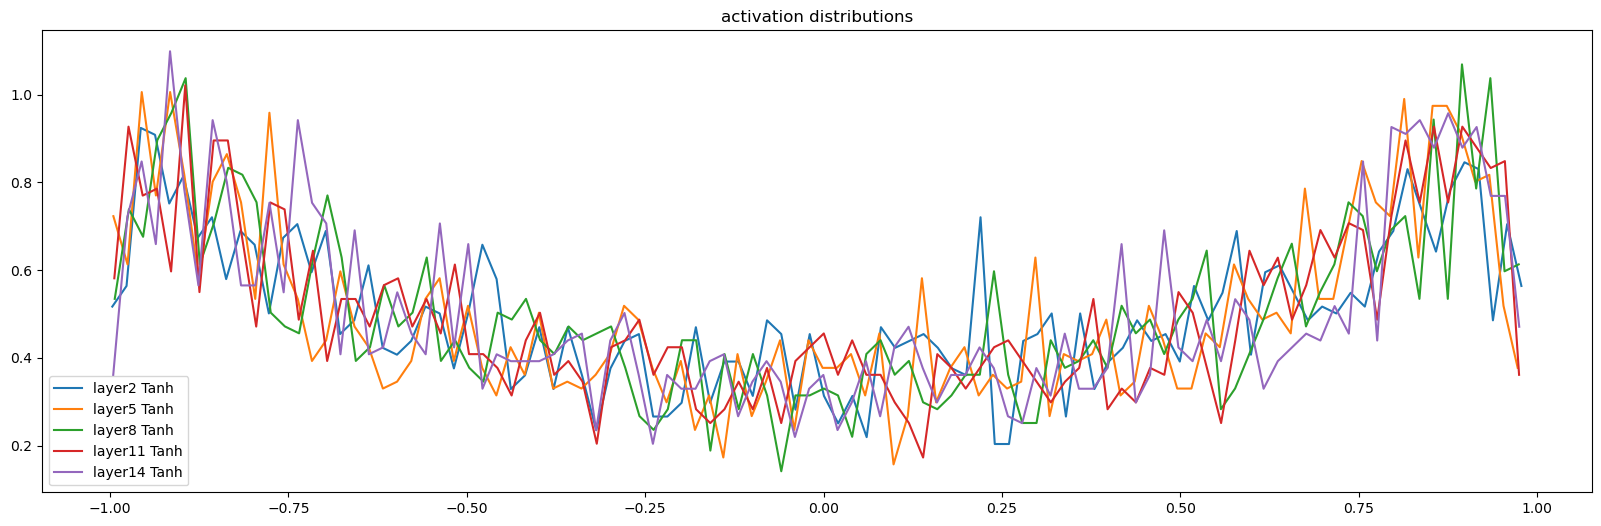

In [100]:
# ============================================================
# 诊断图 1：各层 Tanh 激活值的分布
# 观察要点：
#   - 各层分布形状和宽度应大致一致（层间一致性最重要）
#   - 分布是否逐层收窄（方差坍缩） → 说明增益不足
#   - 分布是否挤到 ±1（饱和） → 说明增益过大
#
# 各指标的健康范围：
#   指标       | 健康范围      | 含义
#   mean       | |mean| < 0.05 | 分布居中，没有偏向一侧
#   std        | 0.5 ~ 0.7    | 值分散但没到饱和区（tanh 输出上限是 1，std 不可能太大）
#   saturated  | < 5%         | 绝大部分神经元在 tanh 线性区，梯度流畅
#
# 如何判断分布健康与否：
#   分布形状              | 含义                                 | 好不好
#   钟形，集中在 0 附近    | 大部分神经元在 tanh 线性区，梯度流畅   | 健康
#   两端 ±1 处有尖峰       | 大量神经元饱和，梯度消失              | 不健康
#   完全均匀分布在 (-1,1)  | 太多值在尾部，部分饱和                | 一般
#   极窄的尖峰在 0 附近    | 方差坍缩，网络没学到有区分度的特征     | 不健康
#
# 不健康的组合（快速诊断）：
#   mean   | std      | saturated | 诊断
#   ~0     | < 0.1    | ~0%       | 方差坍缩：增益太小，激活全挤在 0 附近
#   ~0     | > 0.85   | > 30%     | 严重饱和：增益太大，大量神经元卡死在 ±1
#   > 0.2  | 正常     | 正常      | 分布偏移：权重或数据不对称
#   ~0     | 逐层递减  | 逐层递减  | 逐层衰减：Kaiming 增益不足，信号逐层变弱
#   ~0     | 逐层递增  | 逐层递增  | 逐层膨胀：增益过大，信号逐层放大直到饱和
#
# 理想输出示例：
#   layer 1 (Tanh): mean +0.01, std 0.65, saturated 1.25%
#   layer 3 (Tanh): mean -0.02, std 0.63, saturated 1.10%
#   layer 5 (Tanh): mean +0.00, std 0.61, saturated 0.95%
#   → std 各层一致且在 0.5~0.7，saturated 都 < 5%
# ============================================================
plt.figure(figsize=(20,6))
legend = []

# enumerate(layers[:-1])：
#   layers[:-1] = 去掉最后的输出层（输出层无激活函数，不需要诊断）
#   enumerate()  = 给每层加上索引 i，用于打印 "layer 1"、"layer 3" 等
#   → 产生 (0, Linear), (1, Tanh), (2, Linear), (3, Tanh), ...
for i, layer in enumerate(layers[:-1]):
    
    if isinstance(layer, Tanh):          # 只诊断 Tanh 层的输出分布
    # if isinstance(layer, Linear):          # 只诊断 Linear 层的输出分布
        # layer.out 形状 (32, 100) = (batch_size, n_hidden)
        # 是训练循环中 self.out = torch.tanh(x) 保存下来的该层激活值
        t = layer.out
        # %d=整数, %10s=右对齐占10字符的字符串, %+.2f=带正负号保留2位小数,
        # %.2f%%=保留2位小数后跟字面%（%%转义）
        # (t.abs()>0.97).float().mean()*100 = 饱和比例：|输出|>0.97 的占百分之几
        print('layer %d (%s): mean %+.2f, std %.2f, saturated %.2f%%' % (
            i, 
            layer.__class__.__name__,  
            t.mean(), 
            t.std(), 
            (t.abs()>0.97).float().mean()*100
        ))

        # torch.histogram：把 3200 个散点分箱计数，得到分布曲线的坐标
        #   hy = 每个桶的概率密度（y 坐标），hx = 桶边界（比 hy 多 1 个）
        #   density=True → 归一化为概率密度（面积=1），方便不同层对比
        hy, hx = torch.histogram(t, density=True)
        # 用折线图（而非柱状图）画分布，多层叠在一起不会互相遮挡
        # hx[:-1]：去掉最后一个边界，让 x/y 数量对齐
        # .detach()：从计算图脱离，matplotlib 只接受纯数值
        plt.plot(hx[:-1].detach(), hy.detach())
        legend.append(f'layer{i} {layer.__class__.__name__}')
plt.legend(legend)
plt.title('activation distributions')

layer 2 (      Tanh): mean +0.000000, std 3.502096e-03
layer 5 (      Tanh): mean +0.000000, std 3.080663e-03
layer 8 (      Tanh): mean -0.000000, std 2.883572e-03
layer 11 (      Tanh): mean +0.000000, std 2.576882e-03
layer 14 (      Tanh): mean -0.000000, std 2.440742e-03


Text(0.5, 1.0, 'gradient distributions')

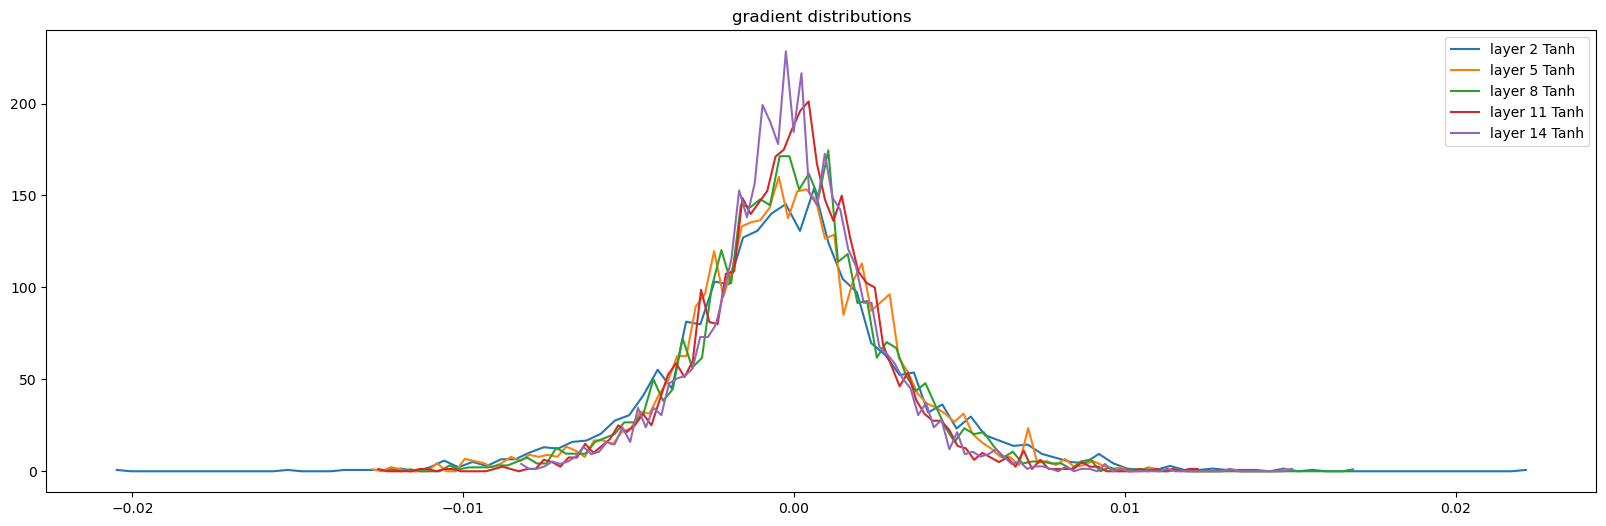

In [101]:
# ============================================================
# 诊断图 2：各层 Tanh 激活值的**梯度**分布
#
# 为什么要看梯度分布？
#   反向传播是链式法则的连乘：∂L/∂x₁ = ∂L/∂x₅ · k₅ · k₄ · k₃ · k₂
#   每个 kᵢ 是该层的局部偏导。如果每层 kᵢ < 1，经过 L 层后梯度衰减为 k^L：
#     k=0.9, 5层 → 0.59（可接受）
#     k=0.5, 5层 → 0.03（消失）
#     k=0.1, 5层 → 0.00001（灾难）
#   所以初始化的目标是让每层 k ≈ 1，不放大也不缩小。
#   不要求各层梯度完全相同——非线性函数天然会带来 2-3 倍差异——
#   但不能让差异随深度指数增长。
#
# 怎么让每层 k ≈ 1？不是直接设偏导，而是间接控制激活值分布：
#   控制权重初始化 → 控制激活值落在什么范围 → 偏导自然 ≈ 1
#   - Linear 层：Kaiming 初始化（Var(W)=1/fan_in）→ 方差不放大
#   - Tanh 层：确保输入在 0 附近 → tanh'(x) ≈ 1
#     - 方法 1：Kaiming + gain=5/3 让前面方差控好，输入不会太大
#     - 方法 2：BN 强制拉回 N(0,1)
#
# 观察要点：
#   - 梯度是否逐层变小（梯度消失） → 深层学不到东西
#   - 梯度是否逐层变大（梯度爆炸） → 训练不稳定
#   - 理想：各层梯度 std 在同一数量级（用 %e 科学计数法对比）
#
# 如何判断（看 std 的科学计数法 %e）：
#   各层 std 差距 < 10 倍（1 个数量级）  → 健康
#   最浅层 vs 最深层差 100 倍以上        → 有问题
#
# 与激活值分布的联动：
#   激活值两端饱和（U 形）→ tanh 导数 ≈ 0 → 梯度逐层缩小（消失）
#   激活值方差坍缩（窄尖峰）→ 信号弱 → 梯度都很小但各层差不多
#   激活值钟形且各层一致   → tanh 导数 ≈ 1 → 梯度各层同数量级（健康）
# ============================================================
plt.figure(figsize=(20,6))
legend = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
    # if isinstance(layer, Linear):
        t = layer.out.grad               # 该层 Tanh 输出的梯度 ∂loss/∂h
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))   
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legend.append(f'layer {i} {layer.__class__.__name__}')
plt.legend(legend)
plt.title('gradient distributions')

In [105]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = { 
        'train': (Xtr, Ytr), 
        'val': (Xdev, Ydev), 
        'test': (Xte, Yte) 
        }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

# put layers into eval mode
for layer in layers:
    layer.training = False

split_loss('train')
split_loss('val')

train 2.4297025203704834
val 2.4278724193573


weight   (27, 10) | mean +0.000000 | std 8.164562e-03 | grad:data ratio: 2.140862e-03
weight  (30, 100) | mean -0.000197 | std 7.656209e-03 | grad:data ratio: 2.132692e-03
weight   (1, 100) | mean -0.000338 | std 5.558964e-03 | grad:data ratio: 1.673825e-03
weight   (1, 100) | mean -0.000227 | std 5.643178e-03 | grad:data ratio: 1.634512e-03
weight (100, 100) | mean -0.000085 | std 6.204983e-03 | grad:data ratio: 1.800840e-03
weight   (1, 100) | mean -0.000505 | std 5.480954e-03 | grad:data ratio: 1.674199e-03
weight   (1, 100) | mean +0.000212 | std 4.732160e-03 | grad:data ratio: 1.396802e-03
weight (100, 100) | mean +0.000014 | std 5.590075e-03 | grad:data ratio: 1.584953e-03
weight   (1, 100) | mean +0.000064 | std 5.094754e-03 | grad:data ratio: 1.487848e-03
weight   (1, 100) | mean -0.000242 | std 4.223072e-03 | grad:data ratio: 1.244516e-03
weight (100, 100) | mean +0.000011 | std 5.252692e-03 | grad:data ratio: 1.508430e-03
weight   (1, 100) | mean -0.000130 | std 4.393407e-03 

Text(0.5, 1.0, 'weight gradient distributions')

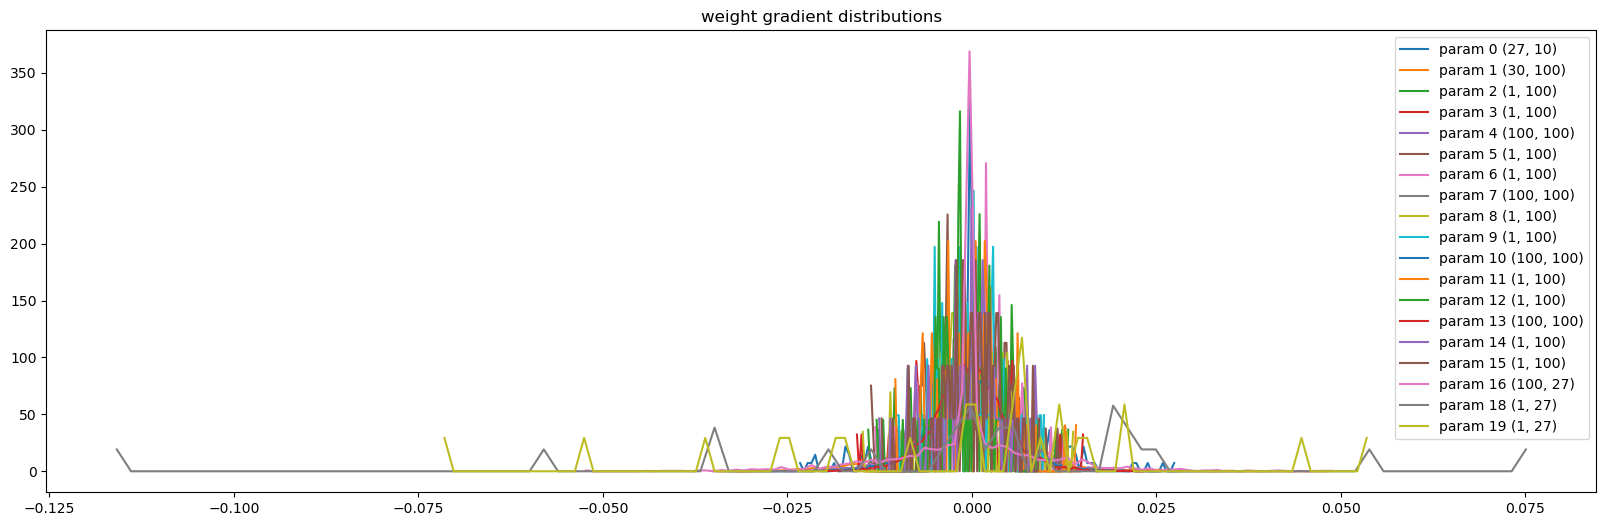

In [103]:
# ============================================================
# 诊断图 3：各权重矩阵的**梯度**分布
# 只看 2D 权重（跳过 1D 偏置），因为权重梯度更能反映学习动态
# grad:data ratio 越接近 1e-3 越好（Karpathy 经验法则）
# ============================================================
plt.figure(figsize=(20,6))
legend = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:                      # 只看权重矩阵，不看偏置
        print('weight %10s | mean %+f | std %e | grad:data ratio: %e' % (
            tuple(p.shape), t.mean(), t.std(), t.abs().mean()/loss.item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legend.append(f'param {i} {tuple(p.shape)}')

plt.legend(legend)
plt.title('weight gradient distributions')

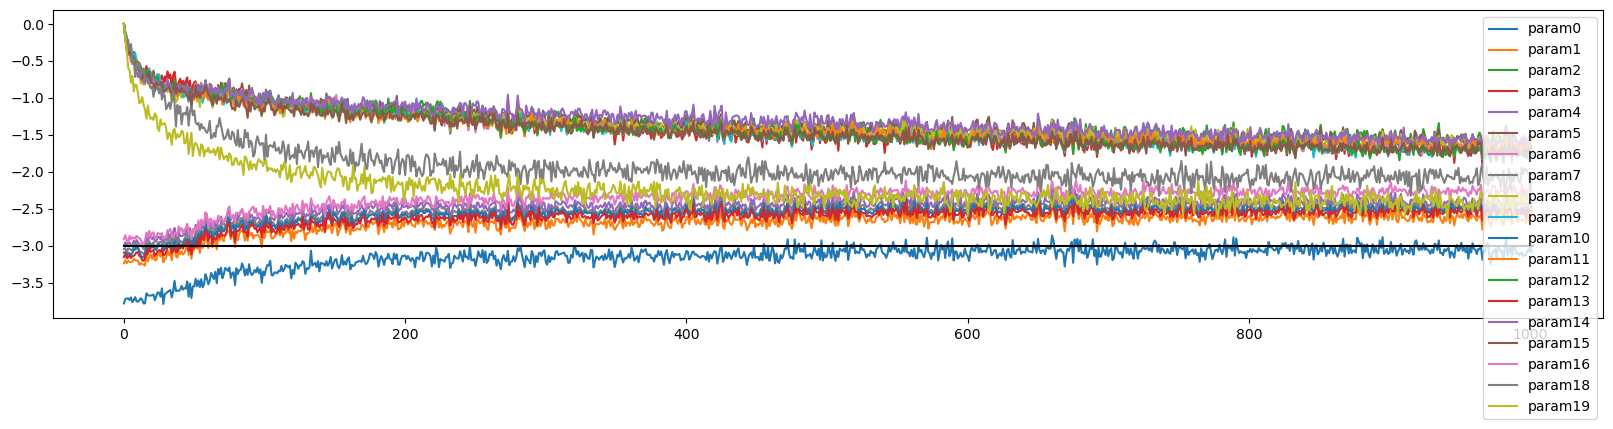

In [104]:
# ============================================================
# 诊断图 4：update-to-data 比率随训练步数的变化
# 公式：ratio = lr × grad.std() / data.std()
# 经验法则：ratio ≈ 1e-3（图中 log10 = -3 的水平线）
#   - 远大于 -3 → 学习率过大，参数剧烈震荡
#   - 远小于 -3 → 学习率过小，参数几乎不动
# ============================================================
plt.figure(figsize=(20, 4))
legends = [] 
for i, p in enumerate(parameters):
    if p.ndim == 2:                      # 只看权重矩阵
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param%d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k')   # 画 -3 参考线
plt.legend(legends)

## 6. 延伸思考：课程定位、工具生态与研究前沿

Karpathy 在视频末尾提到，本讲的内容还比较基础，很多细节没有深入——以下是对三个延伸问题的探讨。

### 6.1 进阶课程推荐

本课程（nn-zero-to-hero）的定位是**从零建立直觉**，强调手写实现而非调用 API。以下课程按推荐优先级排列：

| 优先级 | 课程 | 内容 | 为什么适合作为下一步 |
|--------|------|------|-------------------|
| 1 | [Fast.ai Part 2 "From the Foundations" (2019)](https://course19.fast.ai/part2) | 从零实现矩阵乘法、反向传播、优化器、ResNet、Transformer | 与 Karpathy 理念最接近——"从头造轮子"，但覆盖更广更深 |
| 2 | [Stanford CS224n (2024 YouTube)](https://web.stanford.edu/class/cs224n/) | Attention 机制数学推导、Transformer 架构详解、BERT/GPT 预训练 | Transformer 内部机制讲解最系统，完整视频免费 |
| 3 | [Stanford CS231n](https://cs231n.stanford.edu/) | CNN、优化理论（SGD/Adam/学习率调度）、正则化、可视化 | Karpathy 本人曾参与教授，2025 春季仍在开设（10 周年） |
| 4 | [Umar Jamil (YouTube)](https://umarjamil.org/videos) | 逐行实现 Transformer/LLaMA/Stable Diffusion，配数学讲解 | 风格最像 Karpathy 的 YouTube 创作者，代码和 slides 公开 |
| 5 | [MIT 6.S191](https://introtodeeplearning.com/) | Transformer、LLM、扩散模型、强化学习，每年更新 | Reddit r/MachineLearning 高频推荐，2025 版含最新内容 |

**推荐路径：** Karpathy 全系列完成 → Fast.ai Part 2 (2019) → CS224n → Umar Jamil → 专题深入（论文/Hugging Face）

> 注：Fast.ai 有**两个** Part 2：2019 版 "From the Foundations"（从零造轮子，与本课衔接最好）和新版（Stable Diffusion 实现）。推荐先看 2019 版。

### 6.2 PyTorch 诊断工具现状

Karpathy 视频中手写的四种训练诊断，PyTorch 生态中**没有任何一种有完全开箱即用的成熟方案**：

| 诊断 | PyTorch 原生支持 | 第三方工具 |
|------|-----------------|-----------|
| 激活值分布 | `register_forward_hook()` 手动捕获 | 需自己写 hook + `wandb.log()` |
| 梯度分布 | `register_full_backward_hook()` 手动捕获 | `wandb.watch(model, log="all")` 可自动记录梯度直方图 |
| 权重梯度 | `named_parameters()` + `.grad` | TensorBoard `add_histogram()` 可记录 |
| update/data ratio | **无内置支持** | **无现成方案**，仍需手写 |

**可用工具链：**
- **TensorBoard**（`torch.utils.tensorboard`）：`SummaryWriter.add_histogram()` 可记录直方图，但需在训练循环中手动调用
- **Weights & Biases**（wandb）：`wandb.watch()` 能自动记录权重和梯度直方图，但**不支持**激活值监控和 update/data ratio
- **PyTorch 的 hook 机制**：提供了足够的底层能力（前向/反向 hook），但封装程度不高

**结论：** Karpathy 在视频中手写诊断的方式，至今仍是最灵活的做法。生产环境中通常用 wandb + 自定义 hook 组合。

### 6.3 初始化研究现状（Karpathy 讲课 3 年后）

Karpathy 在 2023 年说初始化仍在学术前沿，这个判断依然成立，但方向已发生变化：

#### 大趋势：归一化层极大缓解了初始化问题，但并未完全解决

| 维度 | 2023（Karpathy 讲课时） | 2025-2026（现在） |
|------|----------------------|------------------|
| 主流归一化 | BatchNorm / LayerNorm | **RMSNorm** 成为 LLM 标配（LLaMA、PaLM 等），省去均值中心化，计算更快 |
| 初始化重要性 | 非常重要 | 标准规模模型已基本"够用"；**千亿参数 LLM 训练中仍是关键** |
| 新方向 | Kaiming / Xavier | **muP / U-muP**（ICLR 2025）：改变初始化与学习率的缩放关系，让超参数从小模型直接迁移到大模型 |
| 未解决问题 | 训练不稳定 | LLM 训练中的 loss spike、attention logit 增长仍与初始化/归一化策略相关 |

#### 代表性新工作（2024-2025）

- **U-muP**（ICLR 2025）— 简化的最大更新参数化，小模型调好参数可直接迁移到大模型
- **HyperCloning**（NeurIPS 2024, Apple）— 用小模型的训练好的参数初始化大模型
- **Peri-LN / Keel**（2025）— 重新审视 LayerNorm 放置位置（Pre-Norm vs Post-Norm），发现 Highway 连接可恢复 Post-Norm 稳定性
- **QK LayerNorm + softmax capping**（2024）— 通过规范化 attention logits 来稳定 LLM 训练

#### 本讲内容在现代架构中的位置

```
本讲学到的                          现代 LLM 中的对应
─────────────────────────────────────────────────
BatchNorm                    →    RMSNorm（更简单、更快）
Kaiming init + gain          →    muP（自动缩放，不需手调）
手写训练诊断                  →    wandb + hook（思路一样，工具化了）
Tanh 激活函数                →    GeLU / SwiGLU（更平滑，训练更稳）
5 层 MLP                    →    Transformer（self-attention + FFN）
```

**一句话总结：** 对于普通规模模型，合理初始化 + LayerNorm 已经"够用"；但在千亿参数 LLM 训练中，初始化和归一化的交互仍是活跃的研究前沿。本讲建立的直觉（方差控制、梯度流动、诊断思维）在现代架构中完全适用。